In [2]:
import pandas as pd
import seaborn as sns
# Lendo o arquivo Parquet
df = pd.read_parquet('data/bairros_features.parquet')

print(df)




               bairro codbairro          regiao_adm  codra   area_km2  \
0    FREGUESIA (ILHA)       098  ILHA DO GOVERNADOR     20   4.056414   
1           BANCARIOS       097  ILHA DO GOVERNADOR     20   0.978049   
2              GALEAO       104  ILHA DO GOVERNADOR     20  18.957473   
3                TAUA       101  ILHA DO GOVERNADOR     20   1.672550   
4          PORTUGUESA       103  ILHA DO GOVERNADOR     20   1.186413   
..                ...       ...                 ...    ...        ...   
160             IRAJA       076               IRAJA     14   7.481982   
161      BRAS DE PINA       045               PENHA     11   2.956169   
162      VISTA ALEGRE       075               IRAJA     14   1.254362   
163     VILA DA PENHA       074               IRAJA     14   1.541675   
164         ARGENTINO       166               PENHA     11   0.031769   

     populacao  domicilios  densidade_hab_km2    ips  n_paradas  n_linhas  \
0      15900.0      7629.0        3919.718488 

Aqui obtive uma visão geral dos dados existentes para cada bairro.

In [3]:
dfdemanda = df[['densidade_hab_km2', 'ips']]
dfdemanda['ips'] = 1-dfdemanda['ips']/100
dfdemanda = dfdemanda.rename(columns={'ips': 'ips_invertido'})
dfdemanda['densidade_hab_km2'] = (df['densidade_hab_km2'] - df['densidade_hab_km2'].min()) / (df['densidade_hab_km2'].max() - df['densidade_hab_km2'].min())
dfdemanda['ips_invertido'] = (dfdemanda['ips_invertido'] - dfdemanda['ips_invertido'].min()) / (dfdemanda['ips_invertido'].max() - dfdemanda['ips_invertido'].min())
print(dfdemanda)

     densidade_hab_km2  ips_invertido
0             0.079105       0.488464
1             0.228988       0.488464
2             0.021880       0.488464
3             0.320717       0.488464
4             0.338600       0.488464
..                 ...            ...
160           0.232465       0.544056
161           0.308657       0.626675
162           0.113740       0.544056
163           0.288358       0.544056
164                NaN       0.626675

[165 rows x 2 columns]


Aqui criei uma planilha contendo os indicadores de demanda normalizados.

In [4]:
dfidemanda = (dfdemanda['densidade_hab_km2'] + dfdemanda['ips_invertido'])/2
print(dfidemanda)

0      0.283784
1      0.358726
2      0.255172
3      0.404590
4      0.413532
         ...   
160    0.388261
161    0.467666
162    0.328898
163    0.416207
164         NaN
Length: 165, dtype: float64


Aqui fiz a média dos indicadores de demanda, formando um índice único. Vou fazer o mesmo para formar o índice de oferta.

In [5]:
dfoferta = df[['cobertura_400m', 'n_paradas', 'n_linhas', 'headway_medio_min']]
dfoferta = dfoferta.rename(columns={'n_paradas': 'paradas_km2'})
dfoferta = dfoferta.rename(columns={'headway_medio_min': 'headway_inv'})
dfoferta['paradas_km2'] = df['n_paradas']/df['area_km2']
dfoferta['headway_inv'] = 1/df['headway_medio_min']
dfoferta['paradas_km2'] = (dfoferta['paradas_km2'] - dfoferta['paradas_km2'].min()) / (dfoferta['paradas_km2'].max() - dfoferta['paradas_km2'].min())
dfoferta['headway_inv'] = (dfoferta['headway_inv'] - dfoferta['headway_inv'].min()) / (dfoferta['headway_inv'].max() - dfoferta['headway_inv'].min())
dfoferta['n_linhas'] = (df['n_linhas'] - df['n_linhas'].min()) / (df['n_linhas'].max() - df['n_linhas'].min())
dfoferta['cobertura_400m'] = (df['cobertura_400m'] - df['cobertura_400m'].min()) / (df['cobertura_400m'].max() - df['cobertura_400m'].min())
dfioferta = dfoferta.sum(axis=1)/4

print(dfioferta)

0      0.225637
1      0.437132
2      0.212067
3      0.423253
4      0.441218
         ...   
160    0.510962
161    0.479744
162    0.533192
163    0.457509
164    0.250000
Length: 165, dtype: float64


Montagem do índice:

In [6]:
DTI = (dfidemanda - dfioferta + 1)*50
print(DTI)

0      52.907360
1      46.079707
2      52.155271
3      49.066865
4      48.615671
         ...    
160    43.864936
161    49.396114
162    39.785318
163    47.934941
164          NaN
Length: 165, dtype: float64


<Axes: xlabel='bairro', ylabel='DTI'>

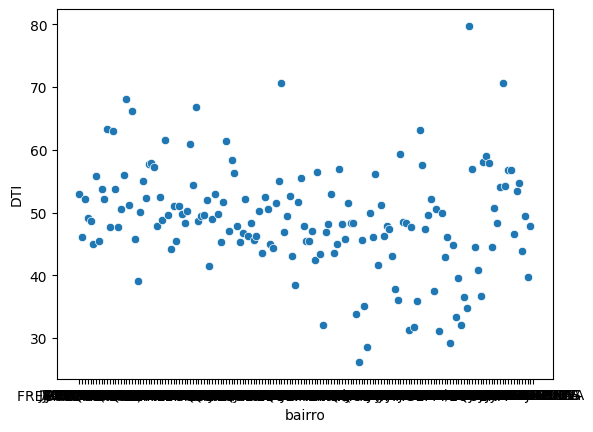

In [11]:
df['DTI'] = DTI
sns.scatterplot(x='bairro', y='DTI', data=df)


Aqui, plotei os pontos de DTI por bairro, para tentar enxergar padrões de concentração e outliers, para determinar métricas. Consegui enxergar uma concentração entre 40 e 60.

In [12]:
Bom = df[df['DTI'] < 40]
print(Bom)

                        bairro codbairro          regiao_adm  codra  \
21                       ZUMBI       092  ILHA DO GOVERNADOR     20   
78   IMPERIAL DE SAO CRISTOVAO       010       SAO CRISTOVAO      7   
88                      CENTRO       005              CENTRO      2   
100                CIDADE NOVA       008        RIO COMPRIDO      3   
101          PRACA DA BANDEIRA       032              TIJUCA      8   
103                   MARACANA       035         VILA ISABEL      9   
104                     GLORIA       016            BOTAFOGO      4   
114                   FLAMENGO       015            BOTAFOGO      4   
115                LARANJEIRAS       017            BOTAFOGO      4   
119                COSME VELHO       019            BOTAFOGO      4   
121                   BOTAFOGO       020            BOTAFOGO      4   
122                       URCA       022            BOTAFOGO      4   
128                    HUMAITA       021            BOTAFOGO      4   
130   

Aqui eu coletei os bairros com melhores DTI e foi possível enxergar que esses bairros em sua grande maioria são bairros considerados nobres. Também é possível ver que o IPS é muito alto, o que indica uma baixa demanda social. Os bairros que não possuem IPS alto, possuem um alto número de paradas em conjunto com uma baixa densidade populacional.

In [14]:
Ruim = df[df['DTI'] > 60]
print(Ruim)

                 bairro codbairro          regiao_adm  codra    area_km2  \
10               PAVUNA       114              PAVUNA     25    8.311428   
12      PARQUE COLUMBIA       159              PAVUNA     25    1.517139   
17                ACARI       111              PAVUNA     25    1.605529   
19         COSTA BARROS       113              PAVUNA     25    1.814837   
31                 MARE       157    COMPLEXO DA MARE     30    4.268773   
40            PACIENCIA       148          SANTA CRUZ     19   27.418044   
42   COMPLEXO DO ALEMAO       156  COMPLEXO DO ALEMÃO     29    2.960863   
53           SANTA CRUZ       149          SANTA CRUZ     19  125.044629   
73          JACAREZINHO       155         JACAREZINHO     28    0.943877   
123      CIDADE DE DEUS       118      CIDADE DE DEUS     34    1.273028   
141             ROCINHA       154             ROCINHA     27    1.437199   
153            GERICINO       160               BANGU     17    2.534311   

     popula

Aqui vemos o contrário, em sua maior parte temos bairros conhecidos por terem comunidades que vivem em constante conflito com o Estado. Demonstram baixo IPS e alta densidade populacional, o headway medio não aparenta muita variação em comparação com os melhores DTIs, isso indica que o pouco serviço flui igualmente.